# 01 · Análisis Exploratorio de Datos
## LLM Classification Finetuning · Kaggle Competition
Predicción de preferencias humanas en batallas entre LLMs (Chatbot Arena)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('ggplot')
pd.set_option('display.max_colwidth', 100)

# Verificar archivos disponibles
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/llm-classification-finetuning/sample_submission.csv
/kaggle/input/competitions/llm-classification-finetuning/train.csv
/kaggle/input/competitions/llm-classification-finetuning/test.csv


In [2]:
BASE_PATH = '/kaggle/input/competitions/llm-classification-finetuning'

train = pd.read_csv(f'{BASE_PATH}/train.csv')
test  = pd.read_csv(f'{BASE_PATH}/test.csv')
sub   = pd.read_csv(f'{BASE_PATH}/sample_submission.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Sub shape:   {sub.shape}')

Train shape: (57477, 9)
Test shape:  (3, 4)
Sub shape:   (3, 4)


In [3]:
train.head(2)

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain percentage of females on managerial positions?"",""...","[""The question of whether it is morally right to aim for a certain percentage of females in mana...","[""As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage license and marriage certificate?"",""How can I get both...","[""A marriage license is a legal document that allows a couple to get married. It is issued by a ...","[""A marriage license and a marriage certificate are two different legal documents that have sepa...",0,1,0


In [4]:
print(train.dtypes)
print()
print("Valores nulos:")
print(train.isnull().sum())

id                 int64
model_a           object
model_b           object
prompt            object
response_a        object
response_b        object
winner_model_a     int64
winner_model_b     int64
winner_tie         int64
dtype: object

Valores nulos:
id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
dtype: int64


                count    pct
winner_model_a  20064  34.91
winner_model_b  19652  34.19
winner_tie      17761  30.90


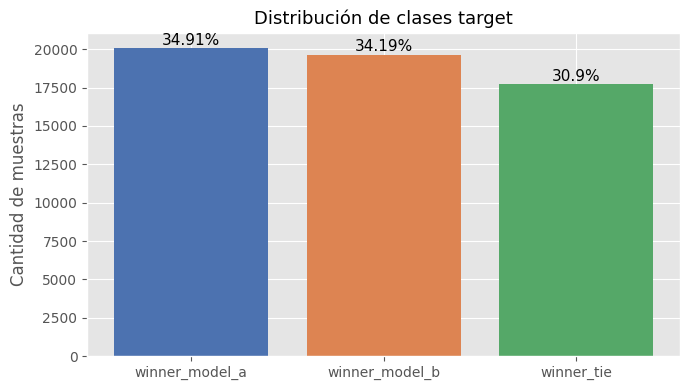

In [5]:
target_cols = ['winner_model_a', 'winner_model_b', 'winner_tie']

counts = train[target_cols].sum()
pct    = counts / len(train) * 100

summary = pd.DataFrame({'count': counts, 'pct': pct.round(2)})
print(summary)

# Visualización
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary.index, summary['count'], color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Distribución de clases target', fontsize=13)
ax.set_ylabel('Cantidad de muestras')
for i, (cnt, p) in enumerate(zip(summary['count'], summary['pct'])):
    ax.text(i, cnt + 200, f'{p}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
all_models = pd.concat([train['model_a'], train['model_b']]).value_counts()
print(f"Total modelos únicos: {all_models.nunique()}")
print()
print(all_models)

Total modelos únicos: 64

gpt-4-1106-preview          7387
gpt-3.5-turbo-0613          7083
gpt-4-0613                  6165
claude-2.1                  5583
claude-instant-1            4136
                            ... 
falcon-180b-chat             286
openchat-3.5-0106            244
qwen1.5-7b-chat              208
qwen1.5-4b-chat              200
mistral-7b-instruct-v0.2     100
Name: count, Length: 64, dtype: int64


In [7]:
# Longitud en caracteres de cada campo de texto
train['len_prompt']     = train['prompt'].str.len()
train['len_response_a'] = train['response_a'].str.len()
train['len_response_b'] = train['response_b'].str.len()
train['len_diff']       = train['len_response_a'] - train['len_response_b']

print(train[['len_prompt', 'len_response_a', 'len_response_b', 'len_diff']].describe().round(1))

       len_prompt  len_response_a  len_response_b  len_diff
count     57477.0         57477.0         57477.0   57477.0
mean        369.2          1377.8          1386.2      -8.3
std        1073.3          1513.9          1537.8    1098.0
min           7.0             4.0             4.0  -52573.0
25%          52.0           408.0           413.0    -427.0
50%          96.0          1076.0          1086.0       0.0
75%         243.0          1862.0          1873.0     416.0
max       33056.0         54058.0         53830.0   43542.0


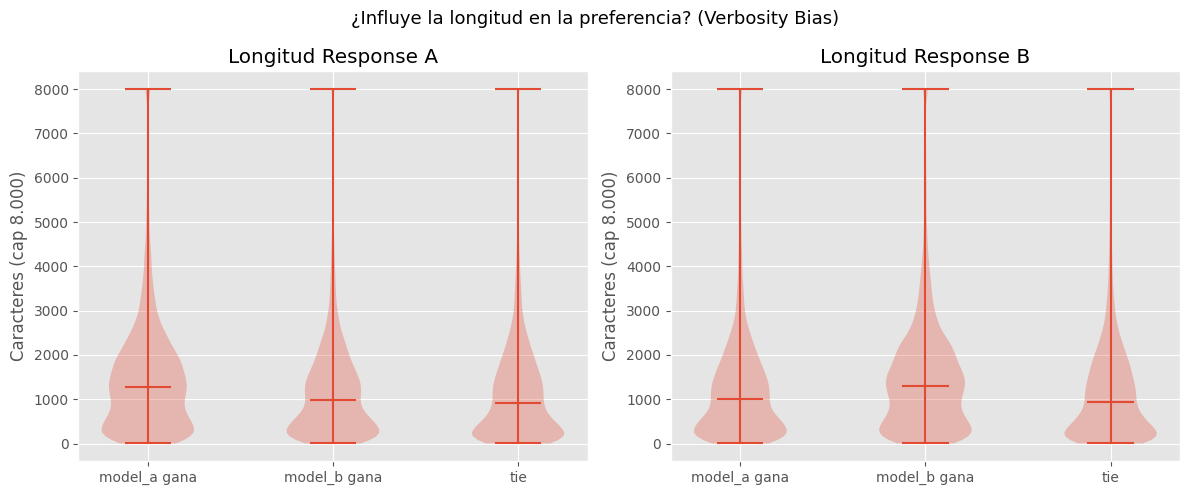

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
                           ['len_response_a', 'len_response_b'],
                           ['Longitud Response A', 'Longitud Response B']):
    groups = [train[train['winner'] == g][col].clip(upper=8000)
              for g in ['model_a', 'model_b', 'tie']]
    
    ax.violinplot(groups, positions=[0, 1, 2], showmedians=True)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['model_a gana', 'model_b gana', 'tie'])
    ax.set_title(title)
    ax.set_ylabel('Caracteres (cap 8.000)')

plt.suptitle('¿Influye la longitud en la preferencia? (Verbosity Bias)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Cuando gana A, ¿es A más larga que B?
a_wins = train[train['winner'] == 'model_a']
b_wins = train[train['winner'] == 'model_b']

print(f"Cuando gana A → A es más larga: {(a_wins['len_response_a'] > a_wins['len_response_b']).mean():.1%}")
print(f"Cuando gana B → B es más larga: {(b_wins['len_response_b'] > b_wins['len_response_a']).mean():.1%}")

Cuando gana A → A es más larga: 61.4%
Cuando gana B → B es más larga: 61.6%


In [12]:
import json
import re

def count_turns(text):
    try:
        # Intento 1: json.loads (más robusto que ast para este tipo de texto)
        parsed = json.loads(text)
        return len(parsed)
    except:
        try:
            # Intento 2: limpiar escapes inválidos y reintentar
            cleaned = re.sub(r'\\(?!["\\/bfnrt]|u[0-9a-fA-F]{4})', r'\\\\', text)
            parsed = json.loads(cleaned)
            return len(parsed)
        except:
            return 1

train['turns'] = train['prompt'].apply(count_turns)
print(train['turns'].value_counts().head(10))
print(f"\nConversaciones multi-turno: {(train['turns'] > 1).mean():.1%}")

turns
1     49938
2      4673
3      1485
4       607
5       311
6       167
7       103
8        60
9        44
10       29
Name: count, dtype: int64

Conversaciones multi-turno: 13.1%


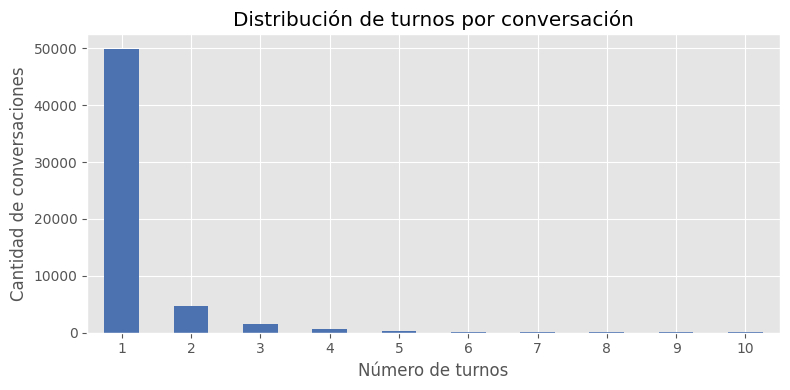

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
train['turns'].clip(upper=10).value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#4C72B0'
)
ax.set_title('Distribución de turnos por conversación')
ax.set_xlabel('Número de turnos')
ax.set_ylabel('Cantidad de conversaciones')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [14]:
print(f"Total filas:          {len(train)}")
print(f"Prompts únicos:       {train['prompt'].nunique()}")
print(f"Prompts duplicados:   {train['prompt'].duplicated().sum()}")

Total filas:          57477
Prompts únicos:       51734
Prompts duplicados:   5743


In [15]:
prompt_counts = train['prompt'].value_counts()

print(f"Prompts que aparecen 1 vez:  {(prompt_counts == 1).sum():>6}")
print(f"Prompts que aparecen 2 veces: {(prompt_counts == 2).sum():>6}")
print(f"Prompts que aparecen 3+ veces: {(prompt_counts >= 3).sum():>6}")
print(f"\nMáximo de apariciones de un mismo prompt: {prompt_counts.max()}")

Prompts que aparecen 1 vez:   48616
Prompts que aparecen 2 veces:   2080
Prompts que aparecen 3+ veces:   1038

Máximo de apariciones de un mismo prompt: 101


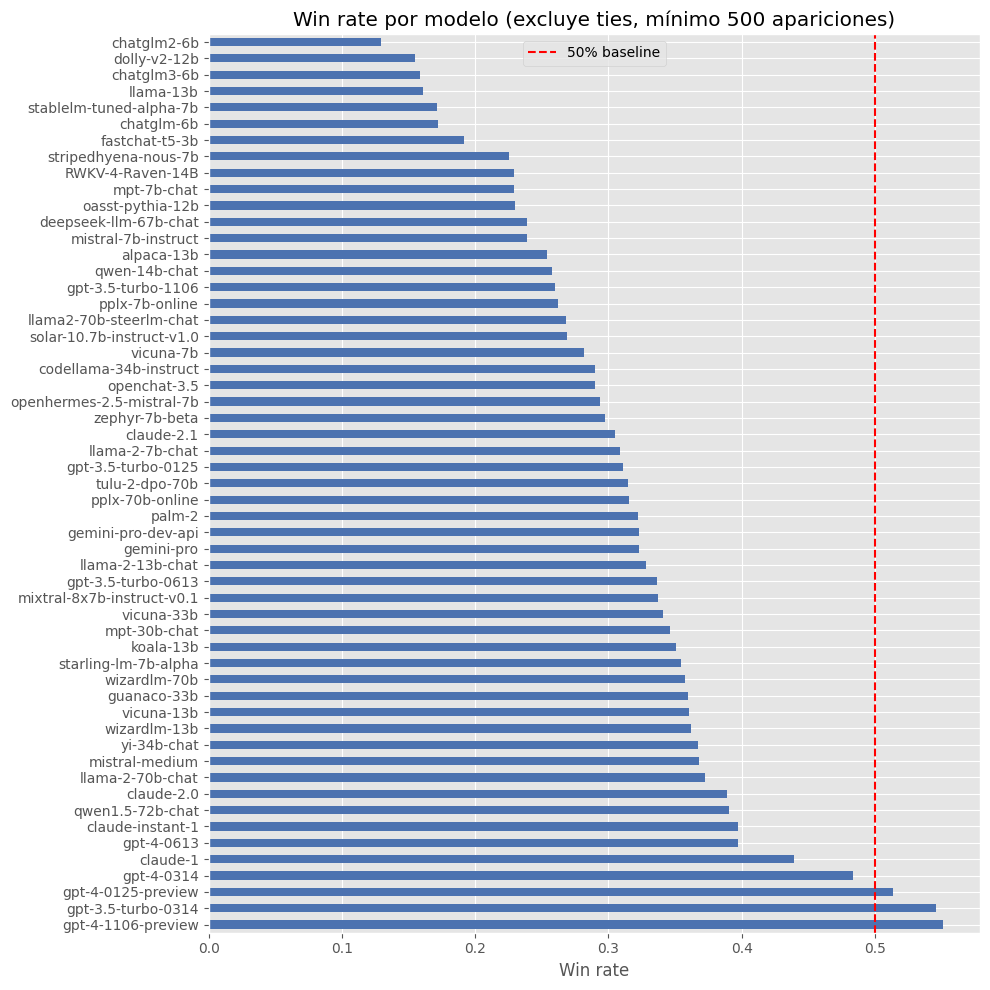

In [20]:
wins_a = train[train['winner'] == 'model_a'].groupby('model_a').size()
wins_b = train[train['winner'] == 'model_b'].groupby('model_b').size()
total  = pd.concat([train['model_a'], train['model_b']]).value_counts()

win_rate = ((wins_a.add(wins_b, fill_value=0)) / total).dropna().sort_values(ascending=False)
win_rate = win_rate[total > 500]  # solo modelos con suficiente muestra

fig, ax = plt.subplots(figsize=(10, 10))
win_rate.plot(kind='barh', ax=ax, color='#4C72B0')
ax.axvline(0.5, color='red', linestyle='--', label='50% baseline')
ax.set_title('Win rate por modelo (excluye ties, mínimo 500 apariciones)')
ax.set_xlabel('Win rate')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
print(f"Tasa de victoria model_a: {train['winner_model_a'].mean():.1%}")
print(f"Tasa de victoria model_b: {train['winner_model_b'].mean():.1%}")
print(f"Diferencia (position bias): {abs(train['winner_model_a'].mean() - train['winner_model_b'].mean()):.1%}")

Tasa de victoria model_a: 34.9%
Tasa de victoria model_b: 34.2%
Diferencia (position bias): 0.7%


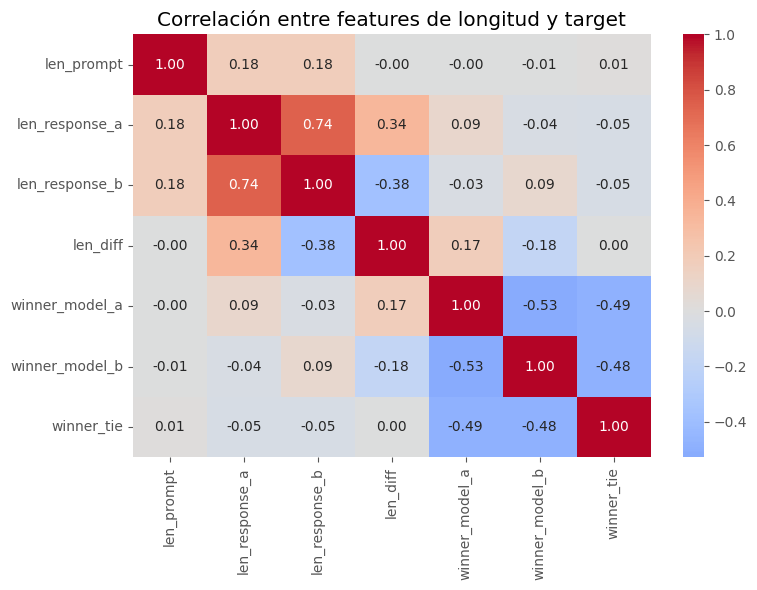

In [22]:
corr_cols = ['len_prompt', 'len_response_a', 'len_response_b',
             'len_diff', 'winner_model_a', 'winner_model_b', 'winner_tie']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(train[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación entre features de longitud y target')
plt.tight_layout()
plt.show()